In [9]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import PIL
import requests

In [10]:
file_path = '/Users/aoyaguip/Downloads/DSI Visualization/tpl-events-feed.csv'
df = pd.read_csv(file_path)

In [11]:
sns.set_style('whitegrid')

In [12]:
print(f"Dataset loaded with {df.shape[0]} rows and {df.shape[1]} columns")
df.head()

Dataset loaded with 4225 rows and 26 columns


,_id,title,startdate,enddate,starttime,endtime,library,location,description,pagelink,...,agegroup2,agegroup3,supportlink,supportlinktext,imagepath,imagetext,imageheight,imagewidth,otherinfo,lastupdated
0,1,Book Sale,2025-05-22,2025-05-24,NaN,NaN,Fairview,NaN,Come find your next favourites to restock your...,https://www.torontopubliclibrary.ca/detail.jsp...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-05-07T16:59:31Z
1,2,Nifty Knitters and Arts Club,2025-03-26,2025-06-25,NaN,NaN,Amesbury Park,NaN,Join us for an hour of relaxing knitting/croch...,https://www.torontopubliclibrary.ca/detail.jsp...,...,Adult,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-03-21T11:10:05Z
2,3,Family Storytime,2025-05-16,2025-06-20,NaN,NaN,Brookbanks,NaN,"Join us Friday mornings for stories, songs and...",https://www.torontopubliclibrary.ca/detail.jsp...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-04-02T14:53:17Z
3,4,Tea & Entertainment,2025-06-06,2025-08-29,NaN,NaN,North York Central Library,NaN,Enjoy watching DVDs in the Library Auditorium ...,https://www.torontopubliclibrary.ca/detail.jsp...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-03-07T11:16:57Z
4,5,Branch Art Exhibit: The Yellow Umbrella Chroni...,2025-05-02,2025-05-30,NaN,NaN,Northern District,NaN,"Throughout the month of May, an exhibit by art...",https://www.torontopubliclibrary.ca/detail.jsp...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{""smallImageURL"":""https://tpl.razuna.com/asset...",2025-05-01T12:50:17Z


In [13]:
print(f"Dataset: {df.shape[0]} rows and {df.shape[1]} columns")

Dataset: 4225 rows and 26 columns


In [14]:
print("\nColumns:")
for col in df.columns:
    print(f"- {col}")



Columns:
- _id
- title
- startdate
- enddate
- starttime
- endtime
- library
- location
- description
- pagelink
- id
- rcid
- eventtype1
- eventtype2
- eventtype3
- agegroup1
- agegroup2
- agegroup3
- supportlink
- supportlinktext
- imagepath
- imagetext
- imageheight
- imagewidth
- otherinfo
- lastupdated


/var/folders/mm/cxzpr9w13817ncqnvg97h0jw0000gn/T/ipykernel_20157/1237427379.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_branches,


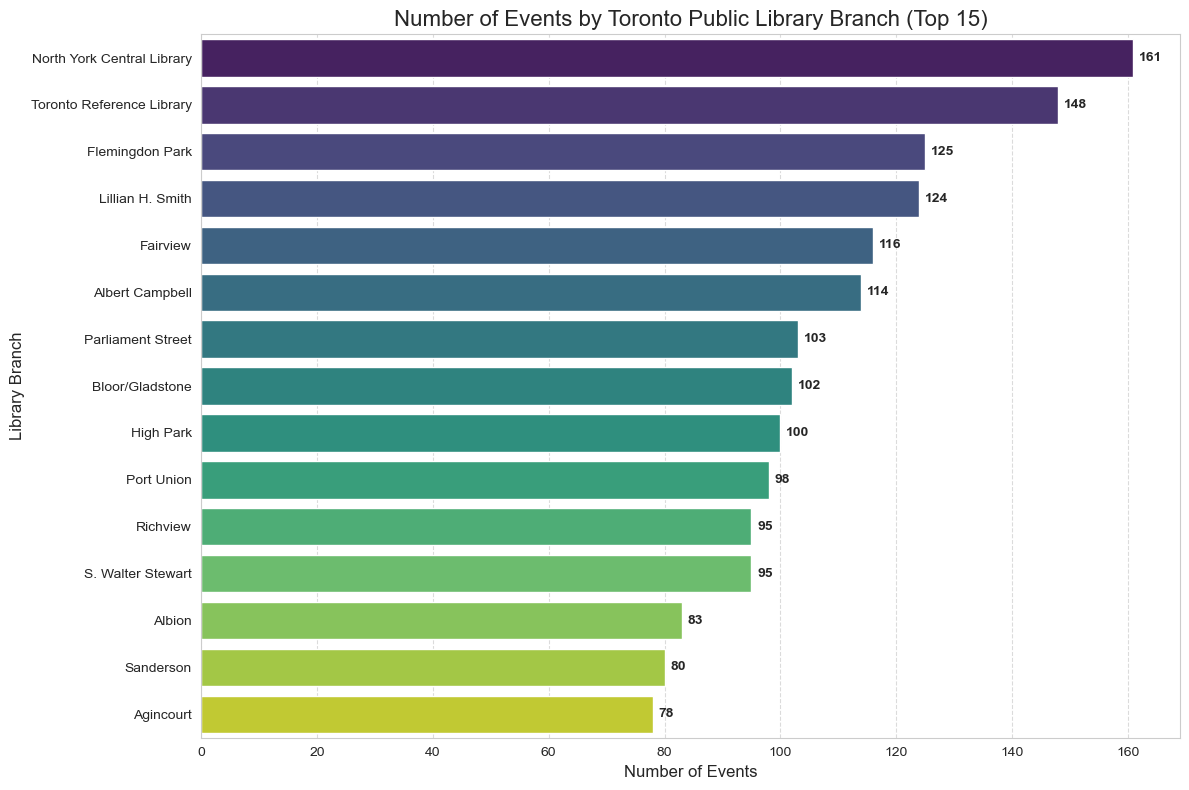

In [22]:
# Events per library
branch_counts = df['library'].value_counts().reset_index()
branch_counts.columns = ['library', 'count']

# Get top 15 libraries by count
top_branches = branch_counts.head(15)

#Matplotlib
fig, ax = plt.subplots(figsize=(12, 8))

sns.barplot(data=top_branches, 
           x='count', 
           y='library', 
           palette='viridis',
           ax=ax)

ax.set_title('Number of Events by Toronto Public Library Branch (Top 15)', fontsize=16)
ax.set_xlabel('Number of Events', fontsize=12)
ax.set_ylabel('Library Branch', fontsize=12)

ax.grid(axis='x', linestyle='--', alpha=0.7)

for i, v in enumerate(top_branches['count']):
    ax.text(v + 1, i, str(v), va='center', fontweight='bold')

plt.tight_layout()

plt.show()

/var/folders/mm/cxzpr9w13817ncqnvg97h0jw0000gn/T/ipykernel_20157/3471743437.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=event_df,


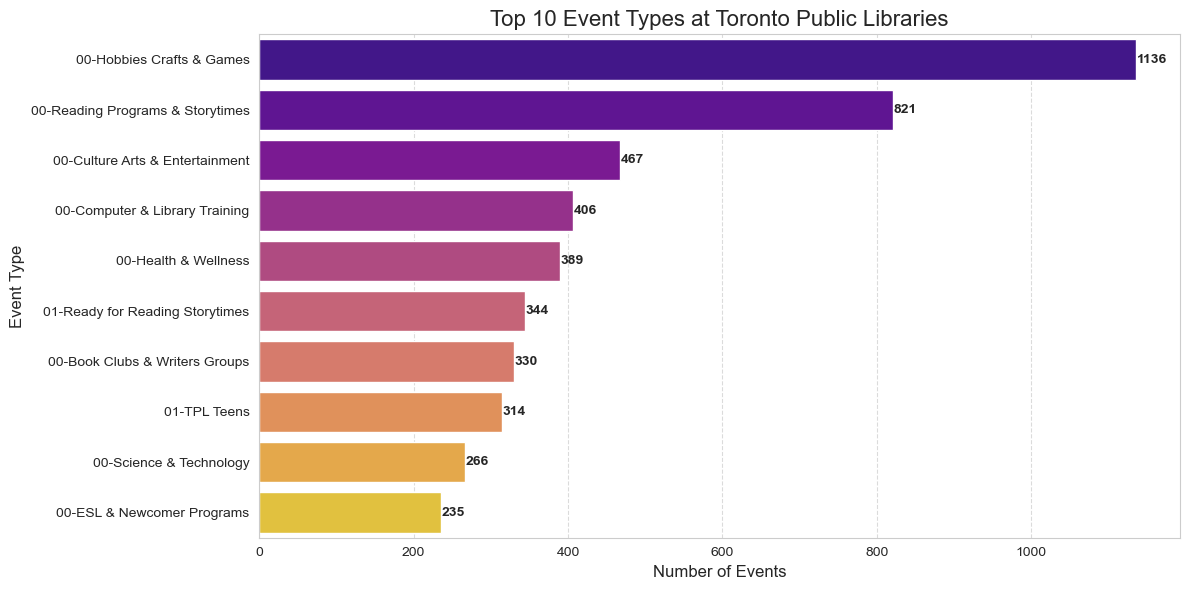

In [23]:
# Event Type

event_types = []

for col in ['eventtype1', 'eventtype2', 'eventtype3']:
    valid_events = df[col].dropna()
    event_types.extend(valid_events)

from collections import Counter
event_counts = Counter(event_types)

event_df = pd.DataFrame({'event_type': list(event_counts.keys()), 
                         'count': list(event_counts.values())})
event_df = event_df.sort_values('count', ascending=False).head(10)
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=event_df, 
           x='count', 
           y='event_type', 
           palette='plasma',
           ax=ax)

ax.set_title('Top 10 Event Types at Toronto Public Libraries', fontsize=16)
ax.set_xlabel('Number of Events', fontsize=12)
ax.set_ylabel('Event Type', fontsize=12)
ax.grid(axis='x', linestyle='--', alpha=0.7)
for i, v in enumerate(event_df['count']):
    ax.text(v + 1, i, str(v), va='center', fontweight='bold')

plt.tight_layout()

plt.show()

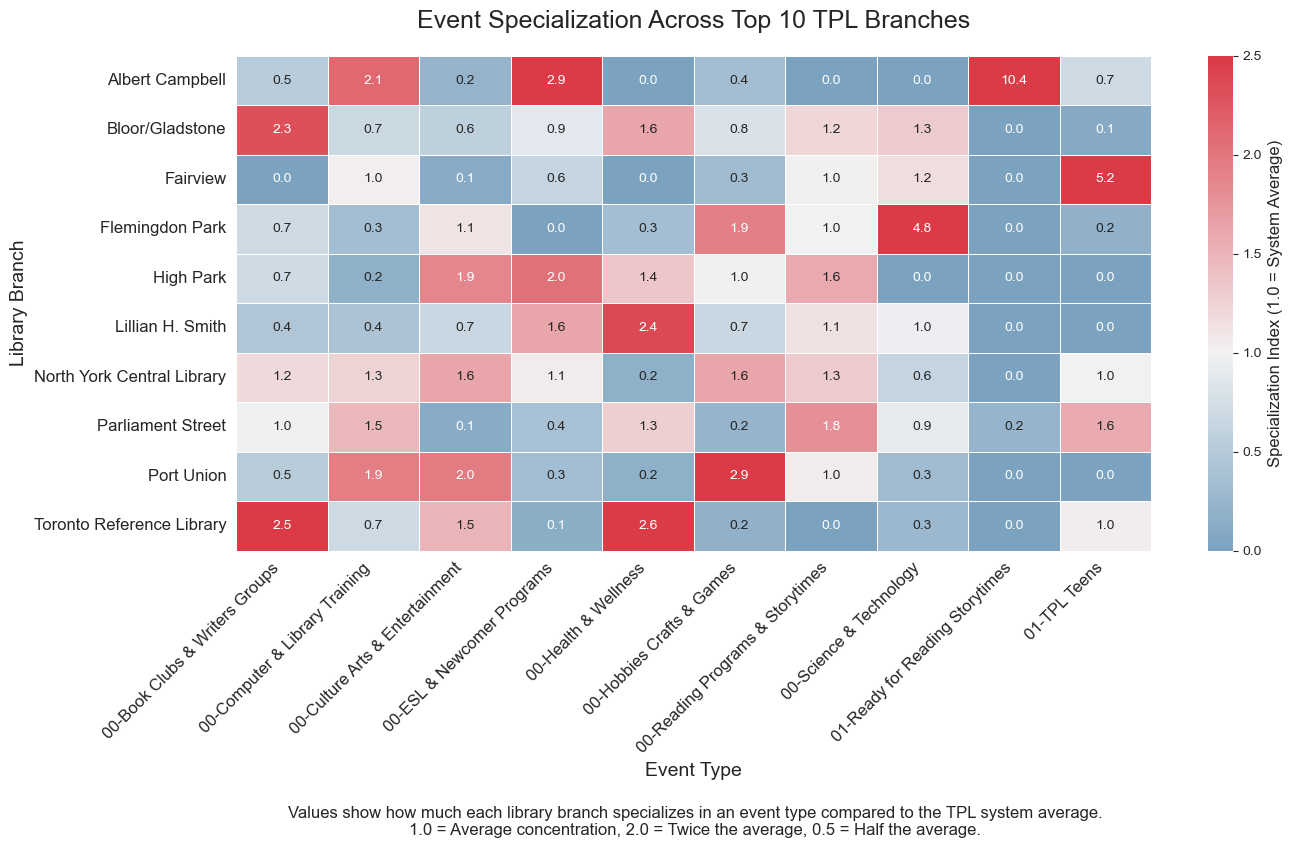

<Figure size 640x480 with 0 Axes>

In [ ]:
#Heatmap event types
top_libraries = df['library'].value_counts().nlargest(10).index.tolist()


top_event_types = df['eventtype1'].value_counts().nlargest(10).index.tolist()

filtered_df = df[df['library'].isin(top_libraries) & df['eventtype1'].isin(top_event_types)]

heatmap_data = pd.crosstab(filtered_df['library'], filtered_df['eventtype1'])

library_percentages = heatmap_data.div(heatmap_data.sum(axis=1), axis=0)
overall_percentages = heatmap_data.sum() / heatmap_data.sum().sum()
specialization_index = library_percentages.div(overall_percentages)
specialization_index = specialization_index.fillna(0)
plt.figure(figsize=(14, 8))

cmap = sns.diverging_palette(240, 10, as_cmap=True)

ax = sns.heatmap(
    specialization_index, 
    cmap=cmap,
    center=1.0,  
    annot=True,  
    fmt='.1f',   
    linewidths=.5,
    vmin=0,      
    vmax=2.5     
)

plt.title('Event Specialization Across Top 10 TPL Branches', fontsize=18, pad=20)
plt.ylabel('Library Branch', fontsize=14)
plt.xlabel('Event Type', fontsize=14)

plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)

cbar = ax.collections[0].colorbar
cbar.set_label('Specialization Index (1.0 = System Average)', fontsize=12)

plt.figtext(0.5, -0.05, 
           "Values show how much each library branch specializes in an event type compared to the TPL system average.\n" +
           "1.0 = Average concentration, 2.0 = Twice the average, 0.5 = Half the average.", 
           ha="center", fontsize=12, bbox={"facecolor":"white", "alpha":0.5, "pad":5})

plt.tight_layout()

plt.show()
plt.savefig('top10_library_specialization.png', dpi=300, bbox_inches='tight')

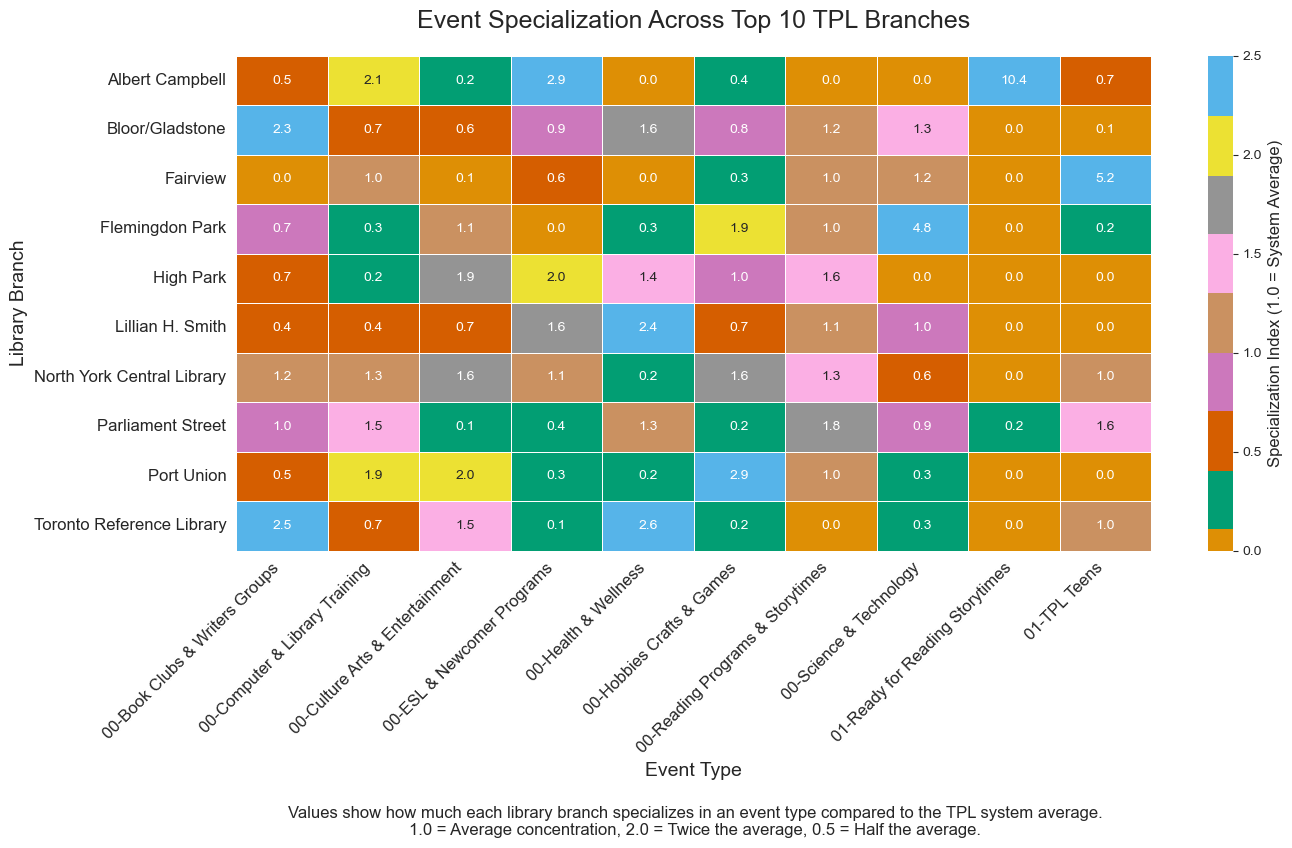

<Figure size 640x480 with 0 Axes>

In [25]:
#[Accessible Version] Heatmap event types
top_libraries = df['library'].value_counts().nlargest(10).index.tolist()


top_event_types = df['eventtype1'].value_counts().nlargest(10).index.tolist()

filtered_df = df[df['library'].isin(top_libraries) & df['eventtype1'].isin(top_event_types)]

heatmap_data = pd.crosstab(filtered_df['library'], filtered_df['eventtype1'])

library_percentages = heatmap_data.div(heatmap_data.sum(axis=1), axis=0)
overall_percentages = heatmap_data.sum() / heatmap_data.sum().sum()
specialization_index = library_percentages.div(overall_percentages)
specialization_index = specialization_index.fillna(0)
plt.figure(figsize=(14, 8))

#Colourblind colour palette
cmap = sns.color_palette("colorblind", as_cmap=True) 

ax = sns.heatmap(
    specialization_index, 
    cmap=cmap,
    center=1.0,  
    annot=True,  
    fmt='.1f',   
    linewidths=.5,
    vmin=0,      
    vmax=2.5     
)

plt.title('Event Specialization Across Top 10 TPL Branches', fontsize=18, pad=20)
plt.ylabel('Library Branch', fontsize=14)
plt.xlabel('Event Type', fontsize=14)

plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)

cbar = ax.collections[0].colorbar
cbar.set_label('Specialization Index (1.0 = System Average)', fontsize=12)

plt.figtext(0.5, -0.05, 
           "Values show how much each library branch specializes in an event type compared to the TPL system average.\n" +
           "1.0 = Average concentration, 2.0 = Twice the average, 0.5 = Half the average.", 
           ha="center", fontsize=12, bbox={"facecolor":"white", "alpha":0.5, "pad":5})

plt.tight_layout()

plt.show()
plt.savefig('top10_library_specialization.png', dpi=300, bbox_inches='tight')

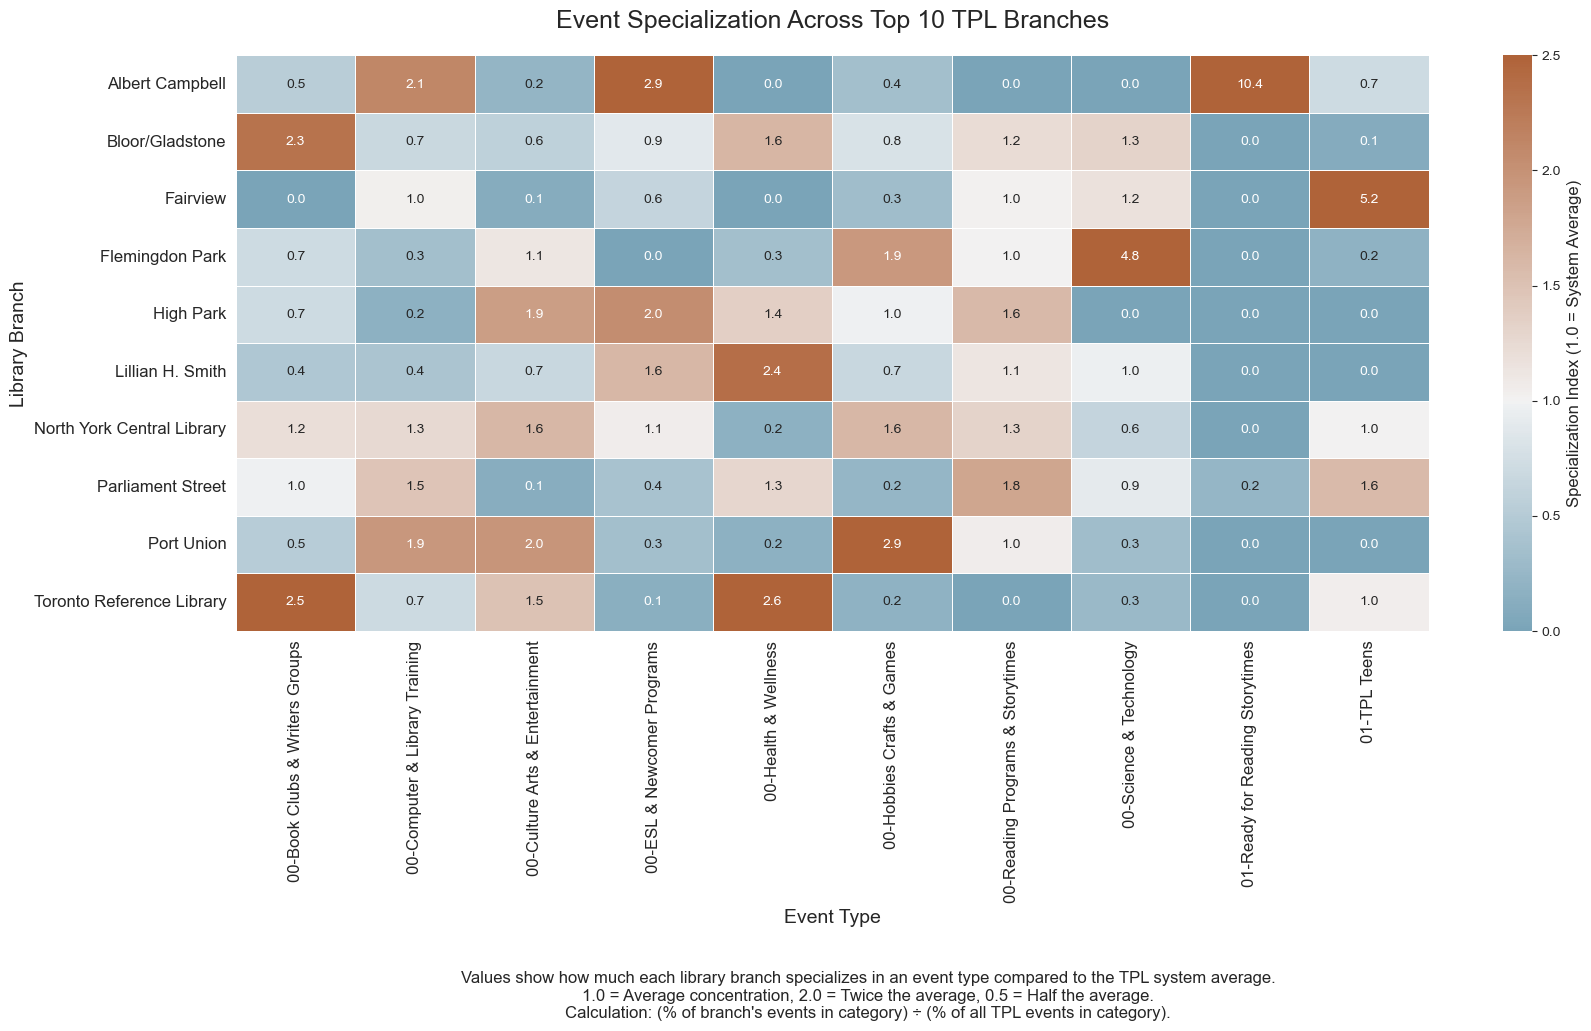

In [27]:
# TPL Heatmap with Accessible Features
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

top_libraries = df['library'].value_counts().nlargest(10).index.tolist()
top_event_types = df['eventtype1'].value_counts().nlargest(10).index.tolist()
filtered_df = df[df['library'].isin(top_libraries) & df['eventtype1'].isin(top_event_types)]
heatmap_data = pd.crosstab(filtered_df['library'], filtered_df['eventtype1'])
library_percentages = heatmap_data.div(heatmap_data.sum(axis=1), axis=0)
overall_percentages = heatmap_data.sum() / heatmap_data.sum().sum()
specialization_index = library_percentages.div(overall_percentages)
specialization_index = specialization_index.fillna(0)

plt.figure(figsize=(18, 10))

#Other colour combo
cmap = sns.diverging_palette(230, 30, as_cmap=True)

ax = sns.heatmap(
    specialization_index, 
    cmap=cmap,
    center=1.0,  
    annot=True,
    fmt='.1f',   
    linewidths=.5,
    vmin=0,      
    vmax=2.5     
)

plt.title('Event Specialization Across Top 10 TPL Branches', fontsize=18, pad=20)
plt.ylabel('Library Branch', fontsize=14)
plt.xlabel('Event Type', fontsize=14)
plt.xticks(rotation=90, ha='center', fontsize=12)
plt.yticks(fontsize=12)
cbar = ax.collections[0].colorbar
cbar.set_label('Specialization Index (1.0 = System Average)', fontsize=12)


plt.figtext(0.5, -0.05, 
           "Values show how much each library branch specializes in an event type compared to the TPL system average.\n" +
           "1.0 = Average concentration, 2.0 = Twice the average, 0.5 = Half the average.\n" +
           "Calculation: (% of branch's events in category) ÷ (% of all TPL events in category).", 
           ha="center", fontsize=12, bbox={"facecolor":"white", "alpha":0.5, "pad":5})

plt.tight_layout(pad=3.0)
plt.savefig('top10_library_specialization_accessible.png', dpi=300, bbox_inches='tight')
plt.show()

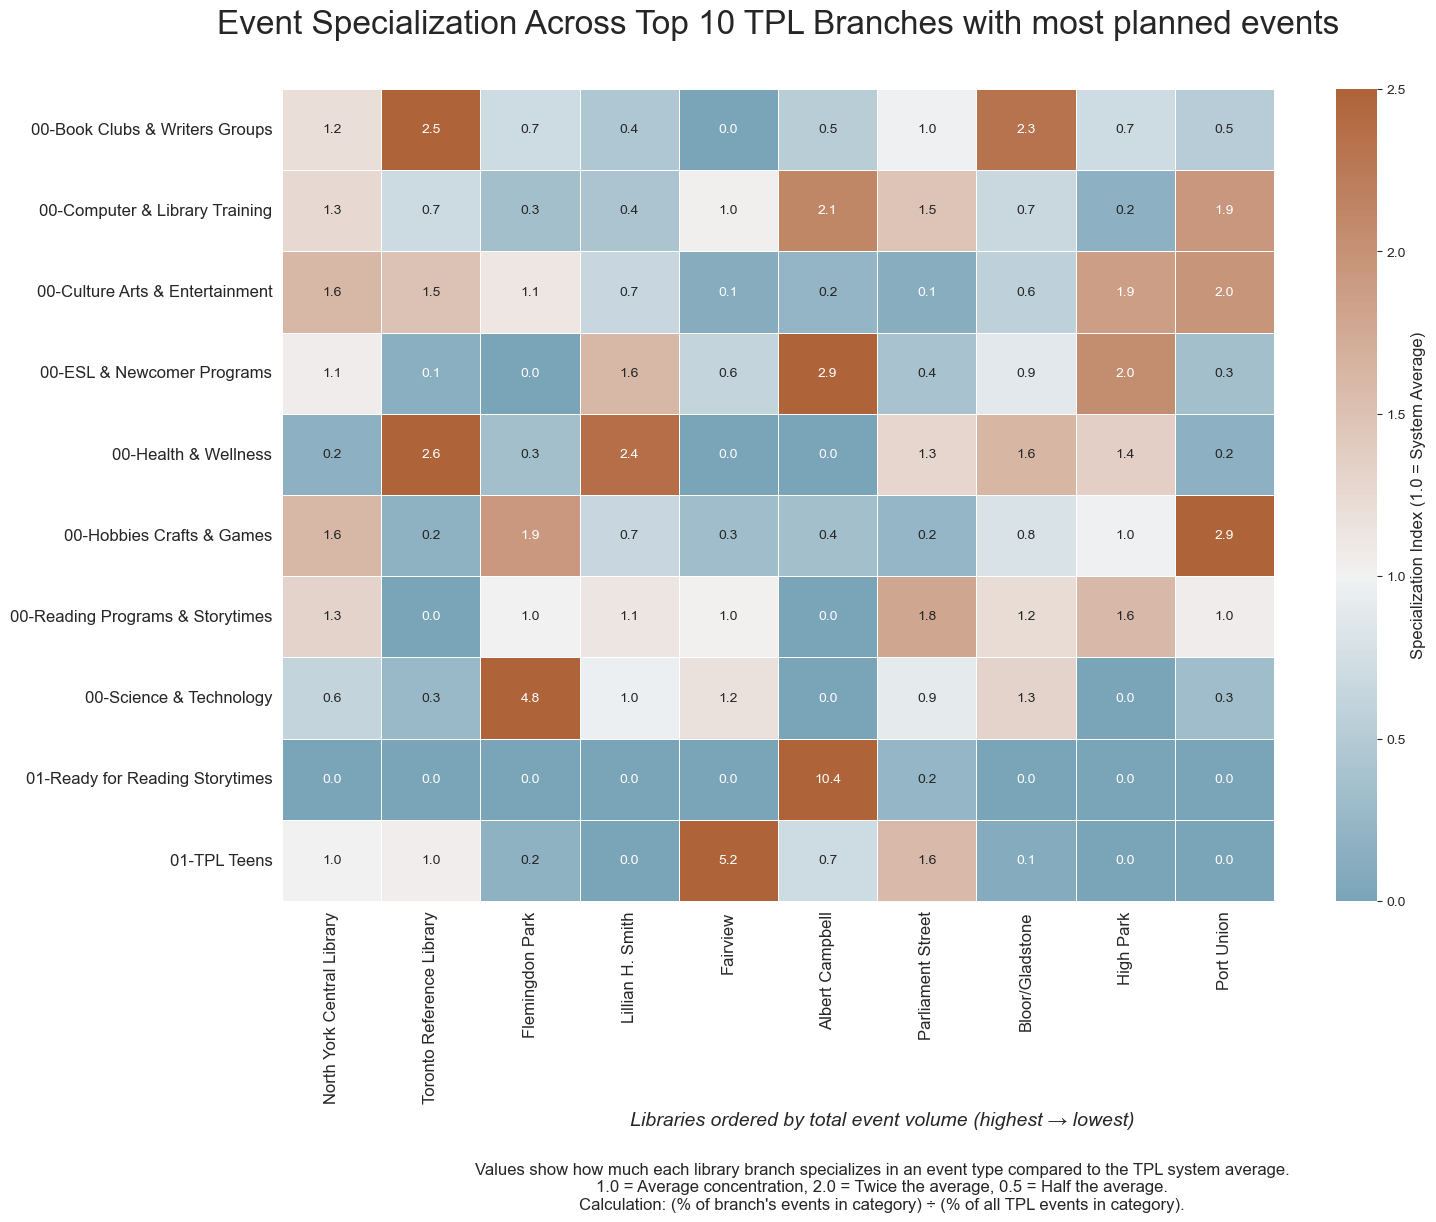

In [33]:
# TPL Heatmap with Accessible Features
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

top_libraries = df['library'].value_counts().nlargest(10).index.tolist()
top_event_types = df['eventtype1'].value_counts().nlargest(10).index.tolist()
filtered_df = df[df['library'].isin(top_libraries) & df['eventtype1'].isin(top_event_types)]
heatmap_data = pd.crosstab(filtered_df['library'], filtered_df['eventtype1'])
library_percentages = heatmap_data.div(heatmap_data.sum(axis=1), axis=0)
overall_percentages = heatmap_data.sum() / heatmap_data.sum().sum()
specialization_index = library_percentages.div(overall_percentages)
specialization_index = specialization_index.fillna(0)

custom_library_order = [
    "North York Central Library",
    "Toronto Reference Library",
    "Flemingdon Park",
    "Lillian H. Smith",
    "Fairview",
    "Albert Campbell",
    "Parliament Street",
    "Bloor/Gladstone",
    "High Park",
    "Port Union"
]

specialization_index = specialization_index.reindex(custom_library_order)

specialization_index_transposed = specialization_index.T

plt.figure(figsize=(16, 14))  

cmap = sns.diverging_palette(230, 30, as_cmap=True)

ax = sns.heatmap(
    specialization_index_transposed, 
    cmap=cmap,
    center=1.0,  
    annot=True,
    fmt='.1f',   
    linewidths=.5,
    vmin=0,      
    vmax=2.5     
)

plt.subplots_adjust(top=0.88, bottom=0.3) 

plt.title('Event Specialization Across Top 10 TPL Branches with most planned events', fontsize=24, pad=40)

plt.xlabel('')
plt.ylabel('')

plt.xticks(fontsize=12, rotation=90, ha='center')
plt.yticks(fontsize=12)

cbar = ax.collections[0].colorbar
cbar.set_label('Specialization Index (1.0 = System Average)', fontsize=12)

plt.figtext(0.5, 0.14,  
           "Libraries ordered by total event volume (highest → lowest)",
           ha="center", fontsize=14, style='italic')

plt.figtext(0.5, 0.08, 
           "Values show how much each library branch specializes in an event type compared to the TPL system average.\n" +
           "1.0 = Average concentration, 2.0 = Twice the average, 0.5 = Half the average.\n" +
           "Calculation: (% of branch's events in category) ÷ (% of all TPL events in category).", 
           ha="center", fontsize=12, bbox={"facecolor":"white", "alpha":0.5, "pad":5})

plt.savefig('top10_library_specialization_final.png', dpi=300, bbox_inches='tight')

plt.show()